In [1]:
# =====================================
# Project: SeeIt - Crop Leaf Disease Classification
# Notebook: 02 - Data Preprocessing
# Purpose: Prepare images for MobileNetV2 training
# =====================================

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Main data folder path
BASE_DIR = Path(r"C:\Users\bhall\OneDrive\Desktop\project\data")

# Dataset folders
color_dir = BASE_DIR / "color"
grayscale_dir = BASE_DIR / "grayscale"
segmented_dir = BASE_DIR / "segmented"

print("Color:", color_dir.exists())
print("Grayscale:", grayscale_dir.exists())
print("Segmented:", segmented_dir.exists())

Color: True
Grayscale: True
Segmented: True


In [2]:
# Import torchvision transforms
# Transforms are used to apply preprocessing steps to images.

from torchvision import transforms

# Select one sample image from color dataset
sample_image_path = next((color_dir / "Apple___Apple_scab").glob("*.JPG"))

# Open image
image = Image.open(sample_image_path)

print("Original image size:", image.size)

# Resize image to 224x224
resize_transform = transforms.Resize((224, 224))

resized_image = resize_transform(image)

print("Resized image size:", resized_image.size)

Original image size: (256, 256)
Resized image size: (224, 224)


In [3]:
# Convert image into tensor format
# Deep learning models understand numbers/tensors, not raw image files.

to_tensor_transform = transforms.ToTensor()

image_tensor = to_tensor_transform(resized_image)

print("Tensor shape:", image_tensor.shape)
print("Minimum pixel value:", image_tensor.min())
print("Maximum pixel value:", image_tensor.max())

Tensor shape: torch.Size([3, 224, 224])
Minimum pixel value: tensor(0.0039)
Maximum pixel value: tensor(0.9647)


In [4]:
# Normalize the image using ImageNet statistics
# MobileNetV2 was pretrained on ImageNet, so we use the same normalization.

normalize_transform = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

normalized_tensor = normalize_transform(image_tensor)

print("Tensor Shape:", normalized_tensor.shape)
print("Minimum Value:", normalized_tensor.min())
print("Maximum Value:", normalized_tensor.max())
print("Mean Value:", normalized_tensor.mean())

Tensor Shape: torch.Size([3, 224, 224])
Minimum Value: tensor(-1.9295)
Maximum Value: tensor(2.3088)
Mean Value: tensor(0.2373)


In [5]:
# Create preprocessing pipeline for training images
# Training images are augmented to improve model generalization.

train_transform = transforms.Compose([

    # Resize image for MobileNetV2
    transforms.Resize((224, 224)),

    # Randomly flip image horizontally
    transforms.RandomHorizontalFlip(p=0.5),

    # Randomly rotate image within ±15 degrees
    transforms.RandomRotation(15),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet statistics
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
# Create preprocessing pipeline for validation and test images
# No random augmentation is applied because evaluation should be fair.

eval_transform = transforms.Compose([

    # Resize image for MobileNetV2
    transforms.Resize((224, 224)),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet statistics
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3088455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3088455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3088455].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3088455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3088455].


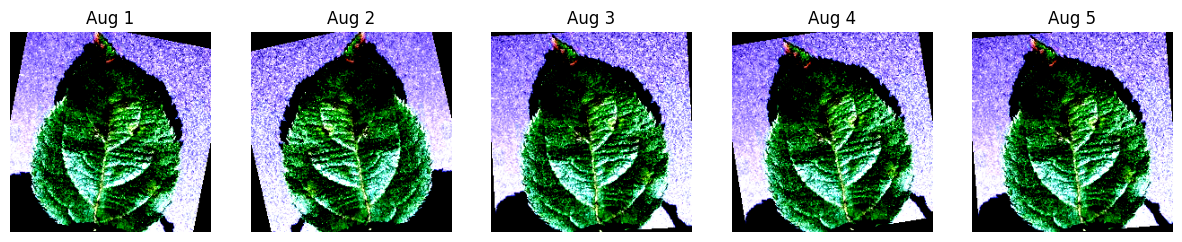

In [7]:
# Visualize multiple augmented versions of the same image
# This helps us understand how training images are randomly changed.

import matplotlib.pyplot as plt

# Open one sample image
sample_image = Image.open(sample_image_path)

# Display 5 augmented versions
plt.figure(figsize=(15, 4))

for i in range(5):
    augmented_tensor = train_transform(sample_image)

    # Convert tensor from CHW to HWC for displaying
    augmented_image = augmented_tensor.permute(1, 2, 0)

    # Display image
    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented_image)
    plt.axis("off")
    plt.title(f"Aug {i+1}")

plt.show()

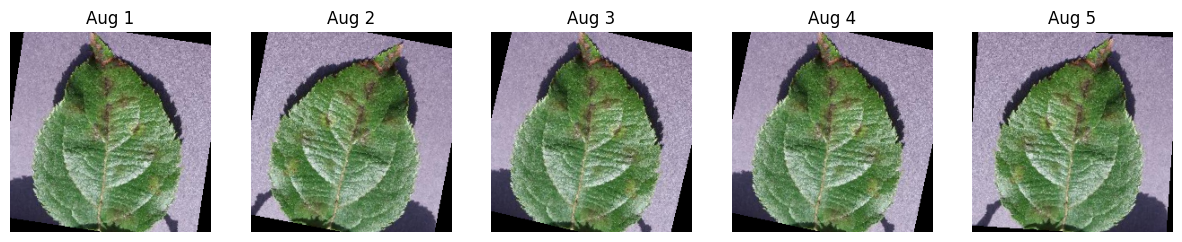

In [8]:
# Display augmented images WITHOUT normalization
# This is only for visualization.

visual_transform = transforms.Compose([

    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15)

])

plt.figure(figsize=(15,4))

for i in range(5):

    img = visual_transform(sample_image)

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.axis("off")

    plt.title(f"Aug {i+1}")

plt.show()

In [9]:
# Import ImageFolder
# ImageFolder automatically reads images and assigns labels based on folder names.

from torchvision.datasets import ImageFolder

# Create dataset using Color images
color_dataset = ImageFolder(
    root=color_dir,
    transform=train_transform
)

print("Total Images :", len(color_dataset))
print("Total Classes:", len(color_dataset.classes))

Total Images : 54297
Total Classes: 38


In [10]:
# Display one sample from the dataset
# Each sample consists of an image tensor and its corresponding label.

image, label = color_dataset[0]

print("Image Shape :", image.shape)
print("Label :", label)
print("Class Name :", color_dataset.classes[label])

Image Shape : torch.Size([3, 224, 224])
Label : 0
Class Name : Apple___Apple_scab


In [11]:
# Import DataLoader
# DataLoader sends images to the model in small batches.

from torch.utils.data import DataLoader

# Create DataLoader for color dataset
color_loader = DataLoader(
    color_dataset,
    batch_size=32,
    shuffle=True
)

print("Total batches:", len(color_loader))

Total batches: 1697


In [12]:
# Get one batch from the DataLoader
# This shows what will be sent to MobileNetV2 during training.

images, labels = next(iter(color_loader))

print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)

Images batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32])


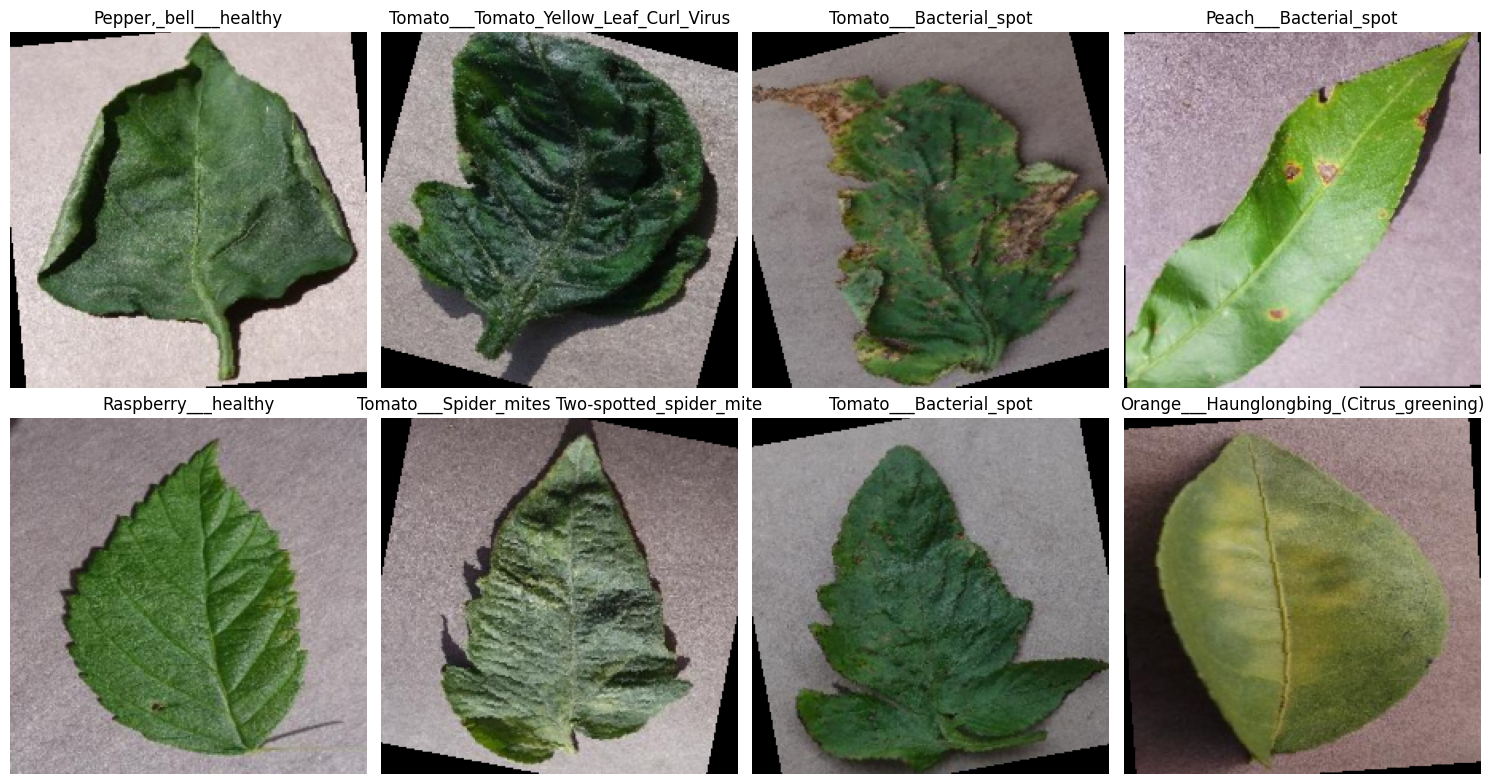

In [13]:
# Display the first 8 images from one batch

import matplotlib.pyplot as plt
import torch

plt.figure(figsize=(15,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    # Convert CHW → HWC
    img = images[i].permute(1,2,0)

    # Undo normalization for visualization
    img = img * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406])

    img = img.numpy().clip(0,1)

    plt.imshow(img)

    plt.title(color_dataset.classes[labels[i]])

    plt.axis("off")

plt.tight_layout()

plt.show()